##CIFAR 10 is a dataset of rbg images btw
  - contains 60000 datasets
  - 10 classes
  - 6000 images per class
  - ratio --> 32 x 32

In [1]:
# Load dataset first from keras
import keras
from keras.datasets import cifar10

# load the pre-shuffled train and test data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


##Visualize the some image data

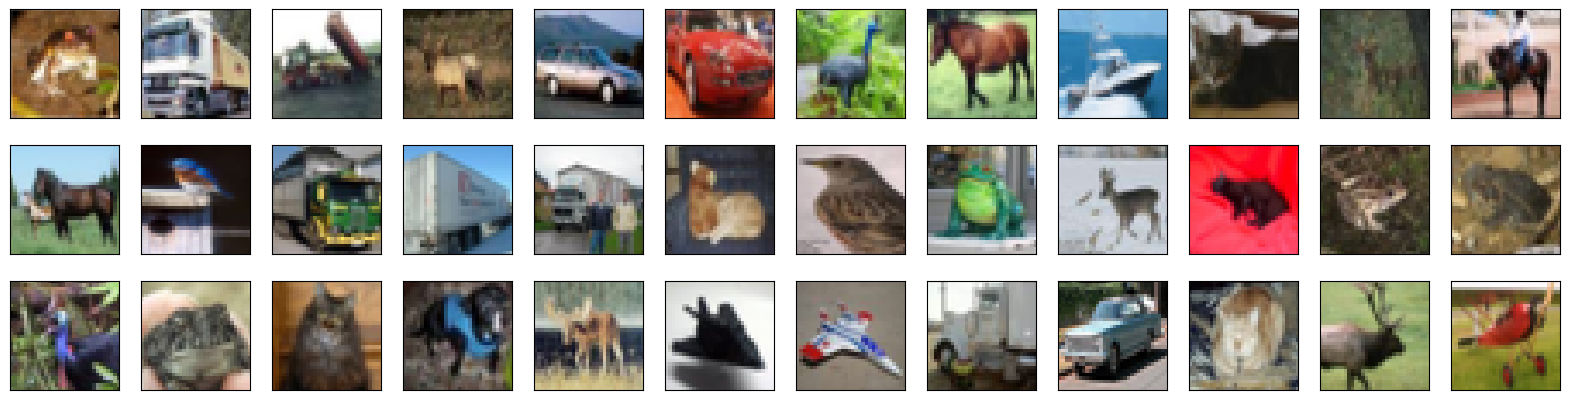

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(20,5))
for i in range(36):
    ax = fig.add_subplot(3, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_train[i]))

##Normalize the data like every other data
 - divide x_train, and x_test by 255

In [3]:
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

##Break Dataset into Training, Testing, and Validation Sets

In [4]:
import tensorflow
from tensorflow import keras

# one-hot encode the labels
num_classes = len(np.unique(y_train))
y_train = tensorflow.keras.utils.to_categorical(y_train, num_classes)
y_test = tensorflow.keras.utils.to_categorical(y_test, num_classes)

# break training set into training and validation sets
(x_train, x_valid) = x_train[5000:], x_train[:5000]
(y_train, y_valid) = y_train[5000:], y_train[:5000]

# print shape of training set
print('x_train shape:', x_train.shape)

# print number of training, validation, and test images
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
print(x_valid.shape[0], 'validation samples')

x_train shape: (45000, 32, 32, 3)
45000 train samples
10000 test samples
5000 validation samples


In [5]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import warnings
warnings.filterwarnings("ignore")


model = Sequential()
model.add(Conv2D(filters=16, kernel_size=3, padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │       512,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,094 (2.06 MB)

 Trainable params: 541,094 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

##Compile the model

In [6]:
#define cost fn and optimiser
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [7]:
# Now Train the model
from keras.callbacks import ModelCheckpoint

# train the model
checkpointer = ModelCheckpoint(filepath='model.weights.best.keras', verbose=1, save_best_only=True)

hist = model.fit(x_train, y_train, batch_size=32, epochs=10,
          validation_data=(x_valid, y_valid), callbacks=[checkpointer],
          verbose=2, shuffle=True)

Epoch 1/10

Epoch 1: val_loss improved from inf to 1.52923, saving model to model.weights.best.keras
1407/1407 - 14s - 10ms/step - accuracy: 0.4237 - loss: 1.5856 - val_accuracy: 0.4708 - val_loss: 1.5292
Epoch 2/10

Epoch 2: val_loss improved from 1.52923 to 1.11825, saving model to model.weights.best.keras
1407/1407 - 4s - 3ms/step - accuracy: 0.5708 - loss: 1.2132 - val_accuracy: 0.6074 - val_loss: 1.1183
Epoch 3/10

Epoch 3: val_loss improved from 1.11825 to 0.98446, saving model to model.weights.best.keras
1407/1407 - 5s - 4ms/step - accuracy: 0.6230 - loss: 1.0770 - val_accuracy: 0.6550 - val_loss: 0.9845
Epoch 4/10

Epoch 4: val_loss improved from 0.98446 to 0.96214, saving model to model.weights.best.keras
1407/1407 - 5s - 3ms/step - accuracy: 0.6513 - loss: 0.9959 - val_accuracy: 0.6736 - val_loss: 0.9621
Epoch 5/10

Epoch 5: val_loss did not improve from 0.96214
1407/1407 - 5s - 3ms/step - accuracy: 0.6700 - loss: 0.9570 - val_accuracy: 0.6570 - val_loss: 0.9845
Epoch 6/10

E

In [8]:
model.load_weights('model.weights.best.keras')

##Predictions

In [9]:
# get predictions on the test set
y_hat = model.predict(x_test)

# define text labels (source: https://www.cs.toronto.edu/~kriz/cifar.html)
cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


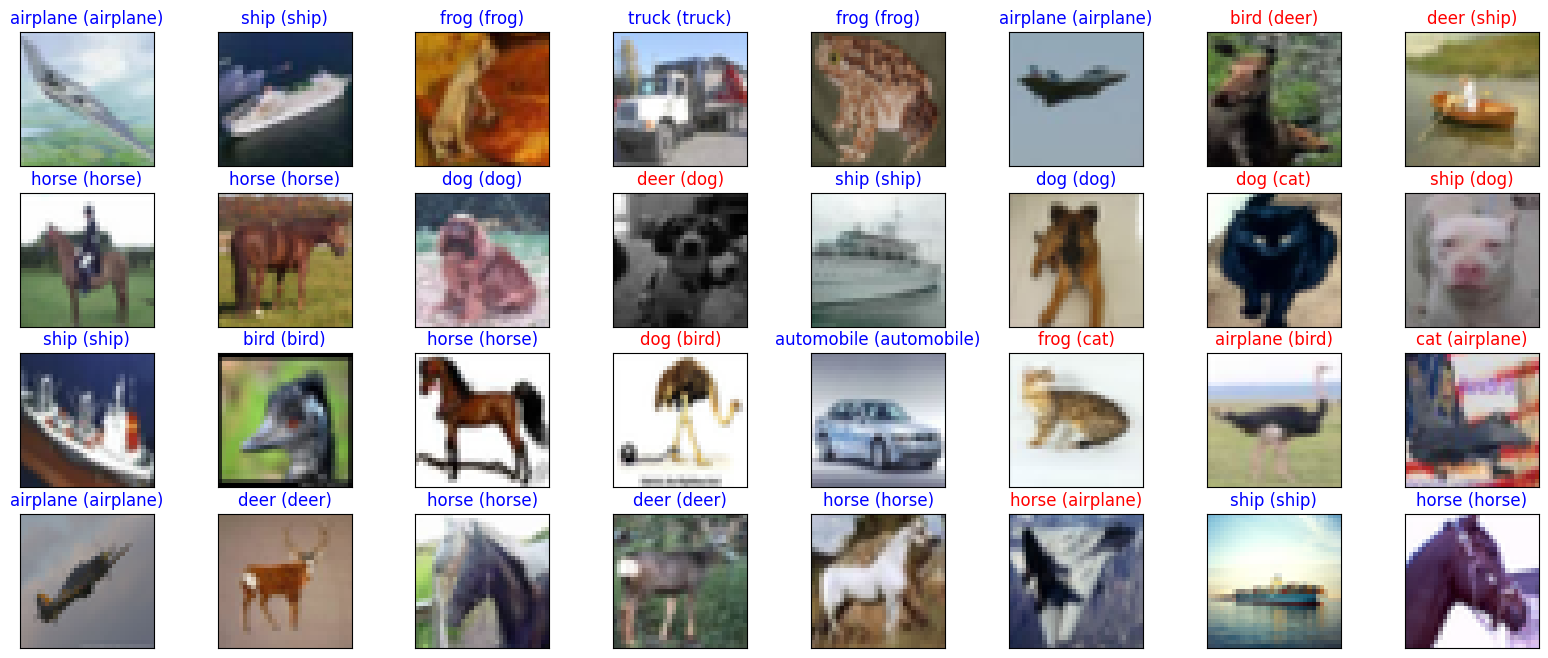

In [10]:
# plot a random sample of test images, their predicted labels, and ground truth
fig = plt.figure(figsize=(20, 8))
for i, idx in enumerate(np.random.choice(x_test.shape[0], size=32, replace=False)):
    ax = fig.add_subplot(4, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_test[idx]))
    pred_idx = np.argmax(y_hat[idx])
    true_idx = np.argmax(y_test[idx])
    ax.set_title("{} ({})".format(cifar10_labels[pred_idx], cifar10_labels[true_idx]), color=("blue" if pred_idx == true_idx else "red"))

##Test accuracy

In [11]:
score = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Accuracy: {score[1]*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7154 - loss: 0.8444
Test Accuracy: 71.37%


In [12]:
score[0]  # test loss
score[1]  # test accuracy

0.713699996471405

## CIFAR-10 is significantly harder than grayscale datasets like MNIST due to:
### 1. RGB images (3 channels) with complex real-world patterns
### 2. High inter-class similarity (cat vs dog, deer vs horse)
### 3. Shallow architecture — only 3 Conv layers, no BatchNormalization
### 4. Limited training — only 10 epochs, no data augmentation
### 5. Simple optimizer (RMSprop) vs adaptive ones like Adam
### Result: 71.37% test accuracy (state-of-the-art ResNet achieves ~93%)